In [5]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib kaggle

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Data Handling & Math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Building & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ML Models (Baseline & Ensemble)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics & Export
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import joblib
import json

In [ ]:
import os
os.makedirs("data", exist_ok=True)

In [7]:
file_path = "dataset/house_prices.csv"
df = pd.read_csv(file_path)
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [8]:
df.info()
# Check total rows, column names, non-null counts, and data types (dtypes)
# Helps identify missing values (Nulls) and incorrect data types


# Display total number of rows and columns (Shape of the DataFrame)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [9]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [10]:
# Calculate the percentage of missing values per column and sort them in descending order
missing_percentage = df.isna().mean().sort_values(ascending=False) * 100

# Display missing percentage per column
print("Percentage of Missing Values Per Column (%):")
print(missing_percentage)

Percentage of Missing Values Per Column (%):
Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64


📝 Dataset Summary & Initial Inspection Findings

#Total Rows:** **187,531** rows (records).
#Column Classification:**
  #Numeric Columns (4):** `Index` (int64), `Price (in rupees)` (float64), `Dimensions` (float64), and `Plot Area` (float64).
  #Text/Categorical Columns (17):** `Title`, `Description`, `Amount(in rupees)`, `location`, `Carpet Area`, `Status`, `Floor`, `Transaction`, `Furnishing`, `facing`, `overlooking`, `Society`, `Bathroom`, `Balcony`, `Car Parking`, `Ownership`, and `Super Area`.
  #(Note: Numerical features like `Amount`, `Carpet Area`, and `Bathroom` are currently stored as text strings and require parsing).*
#Columns with Highest Missing Values:**
  1.# `Dimensions` & `Plot Area`: **100% missing** (completely empty).
  2. #`Society`: **~58.5% missing**.
  3.# `Car Parking`: **~55.1% missing**.
  4. #`Super Area` & `Carpet Area`: **~57.4% & ~43% missing** respectively.

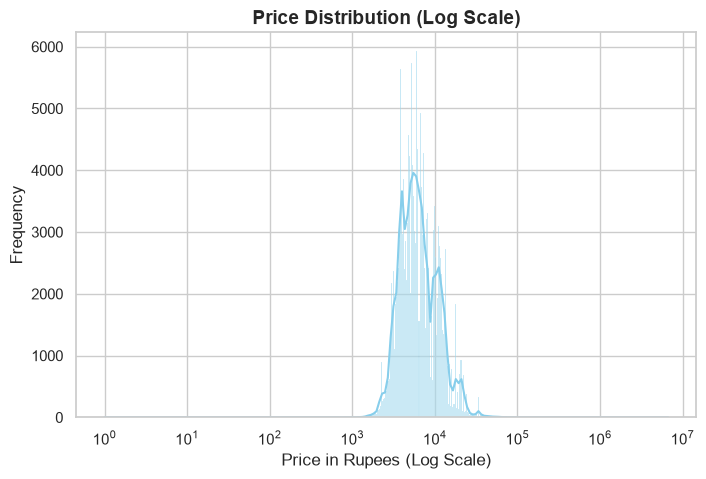

In [14]:
import numpy as np

# 1. Filter out zeros, negative numbers, and NaNs
df_plot = df[df["Price (in rupees)"] > 0].copy()

# 2. Plot the clean data
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(df_plot["Price (in rupees)"], log_scale=True, kde=True, color='skyblue')
plt.title("Price Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Price in Rupees (Log Scale)")
plt.ylabel("Frequency")
plt.show()

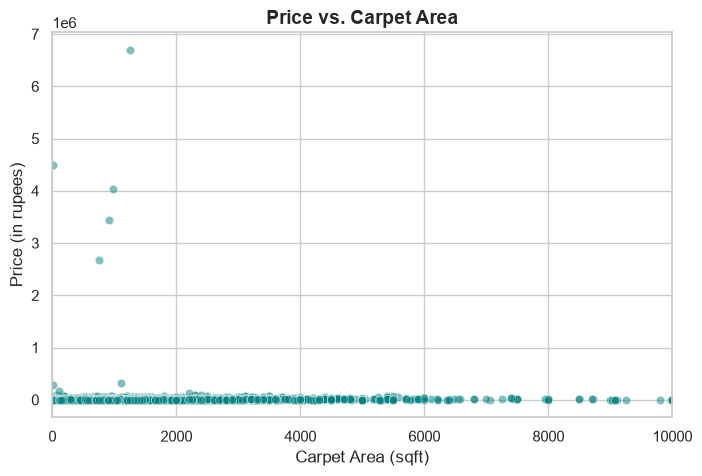

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Extract numerical carpet area directly to avoid KeyError
df['Carpet_Area_num'] = df['Carpet Area'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

plt.figure(figsize=(8, 5))

# Scatter plot of Price vs Carpet Area
sns.scatterplot(x=df['Carpet_Area_num'], y=df['Price (in rupees)'], alpha=0.5, color='teal')

plt.title("Price vs. Carpet Area", fontsize=14, fontweight='bold')
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (in rupees)")
plt.xlim(0, 10000)  # Filter out extreme horizontal values for better display
plt.show()

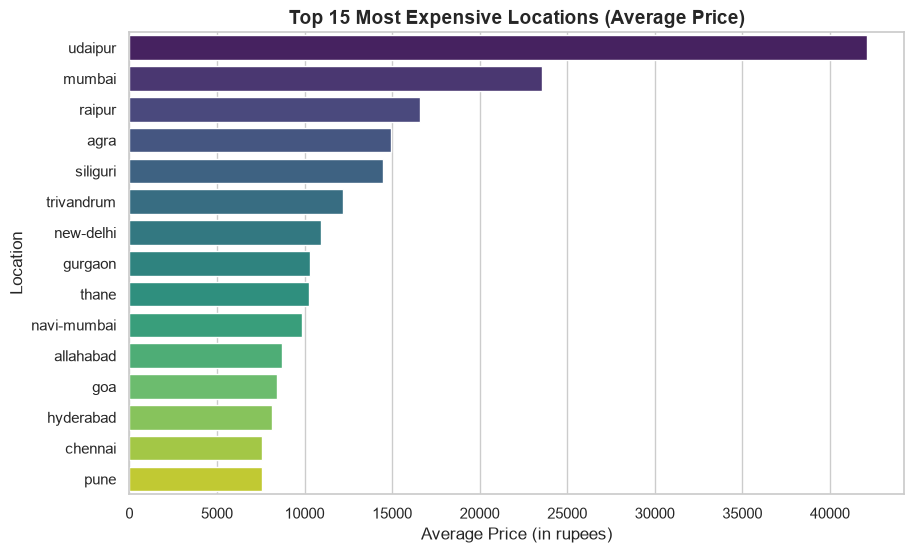

In [17]:
plt.figure(figsize=(10, 6))

# Calculate top 15 locations by average price
top15_locations = df.groupby('location')['Price (in rupees)'].mean().nlargest(15).reset_index()

# Plot horizontal bar chart (Updated with hue and legend=False)
sns.barplot(
    data=top15_locations, 
    x='Price (in rupees)', 
    y='location', 
    hue='location',       # <- Added this!
    palette='viridis', 
    legend=False          # <- Added this!
)

plt.title("Top 15 Most Expensive Locations (Average Price)", fontsize=14, fontweight='bold')
plt.xlabel("Average Price (in rupees)")
plt.ylabel("Location")
plt.show()

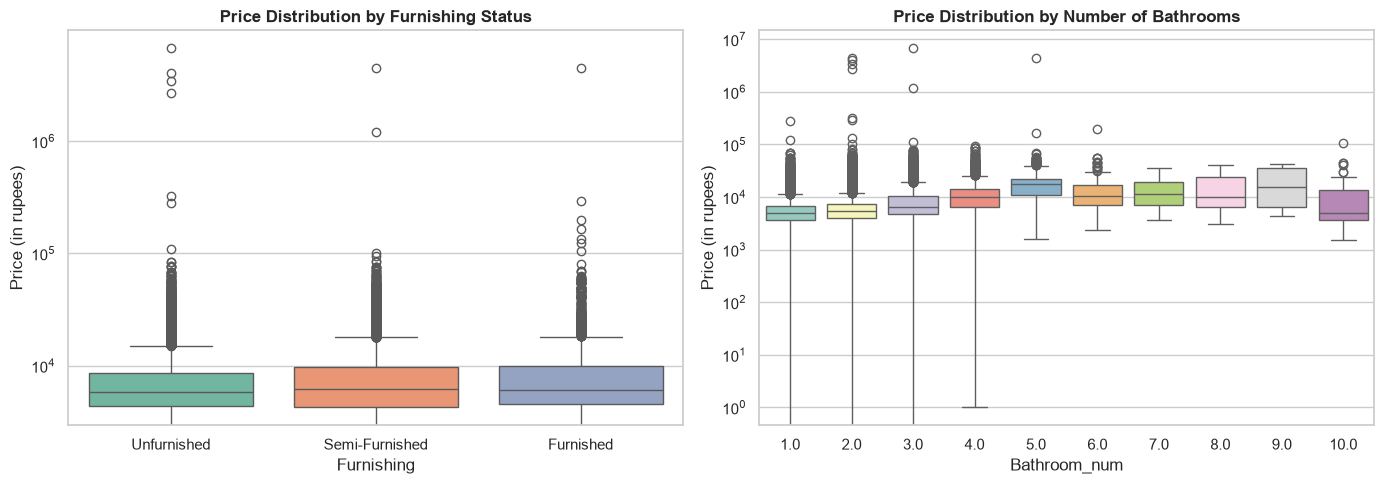

In [18]:
df['Bathroom_num'] = df['Bathroom'].astype(str).str.extract(r'(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot 1: Price by Furnishing Status
sns.boxplot(ax=axes[0], data=df, x='Furnishing', y='Price (in rupees)', hue='Furnishing', palette='Set2', legend=False)
axes[0].set_title("Price Distribution by Furnishing Status", fontsize=12, fontweight='bold')
axes[0].set_yscale('log')

# Boxplot 2: Price by Bathroom Count
sns.boxplot(ax=axes[1], data=df, x='Bathroom_num', y='Price (in rupees)', hue='Bathroom_num', palette='Set3', legend=False)
axes[1].set_title("Price Distribution by Number of Bathrooms", fontsize=12, fontweight='bold')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

> **Insight:** 
> 1. **Price by Furnishing Status:** Properties show relatively similar median price levels across Unfurnished, Semi-Furnished, and Furnished categories, though Furnished and Semi-Furnished options tend to have slightly higher upper ranges and distinct high-end outliers.
> 2. **Price by Number of Bathrooms:** A positive upward trend is observed between the number of bathrooms (from 1 to around 5-6) and property valuation, as more bathrooms typically correlate with larger overall living space and luxury tier properties.

In [19]:
#2.3 Cleaning & Feature Engineering 
# Function to convert text prices (Lac/Cr) into numeric values
def parse_amount(x): 
    if not isinstance(x, str): 
        return None 
    x = x.strip().lower() 
    try: 
        if "lac" in x: 
            return float(x.replace("lac", "").strip()) * 1e5 
        if "cr" in x: 
            return float(x.replace("cr", "").strip()) * 1e7 
        return float(x.replace(",", "")) 
    except ValueError: 
        return None 

# Apply price parsing and drop unusable price rows
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount) 
df = df.dropna(subset=["price_clean"]).copy()

# Verify cleaning result
print(f"Dataset shape after price cleaning: {df.shape}")
df[["Amount(in rupees)", "price_clean"]].head()

Dataset shape after price cleaning: (177847, 24)


,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [20]:
import re

# Function to parse area text and convert all units (sqm, sqyrd, etc.) to sqft
def parse_area_to_sqft(val):
    if not isinstance(val, str) or pd.isna(val):
        return np.nan
    val = val.lower().strip()
    
    # Extract numeric part
    match = re.search(r'(\d+\.?\d*)', val)
    if not match:
        return np.nan
    
    num = float(match.group(1))
    
    # Unit conversions to sqft
    if 'sqm' in val:
        return num * 10.764
    elif 'sqyrd' in val:
        return num * 9.0
    else:
        return num  # Default assumes sqft

# Apply area parsing function
df['carpet_area_sqft'] = df['Carpet Area'].apply(parse_area_to_sqft)
df['super_area_sqft'] = df['Super Area'].apply(parse_area_to_sqft)

# Combine both columns into a single total_area_sqft column
df['total_area_sqft'] = df['carpet_area_sqft'].fillna(df['super_area_sqft'])

# Display sample of parsed values
df[['Carpet Area', 'carpet_area_sqft', 'Super Area', 'super_area_sqft', 'total_area_sqft']].head()

,Carpet Area,carpet_area_sqft,Super Area,super_area_sqft,total_area_sqft
0,500 sqft,500.0,NaN,NaN,500.0
1,473 sqft,473.0,NaN,NaN,473.0
2,779 sqft,779.0,NaN,NaN,779.0
3,530 sqft,530.0,NaN,NaN,530.0
4,635 sqft,635.0,NaN,NaN,635.0


In [15]:
import re

# Function to parse floor numbers from text
def parse_floor(val):
    if not isinstance(val, str) or pd.isna(val):
        return np.nan
    val = val.lower().strip()
    
    if 'ground' in val:
        return 0.0
    elif 'basement' in val:
        return -1.0
    
    # Extract the first number representing the floor level
    match = re.search(r'(\d+)', val)
    return float(match.group(1)) if match else np.nan

# Apply floor parsing
df['floor_clean'] = df['Floor'].apply(parse_floor)

# Display sample of parsed floor values
df[['Floor', 'floor_clean']].head(10)

,Floor,floor_clean
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [21]:
# Parse numbers for Bathroom, Balcony, and Car Parking
df['bathroom_clean'] = df['Bathroom'].astype(str).str.extract(r'(\d+)').astype(float)
df['balcony_clean'] = df['Balcony'].astype(str).str.extract(r'(\d+)').astype(float)
df['parking_clean'] = df['Car Parking'].astype(str).str.extract(r'(\d+)').astype(float)

# Impute missing values
bathroom_median = df['bathroom_clean'].median()
df['bathroom_clean'] = df['bathroom_clean'].fillna(bathroom_median)
df['balcony_clean'] = df['balcony_clean'].fillna(0)
df['parking_clean'] = df['parking_clean'].fillna(0)

# Verify results and missing values count
print("Missing values check for numerical features:")
print(df[['bathroom_clean', 'balcony_clean', 'parking_clean']].isna().sum())

df[['Bathroom', 'bathroom_clean', 'Balcony', 'balcony_clean', 'Car Parking', 'parking_clean']].head()

Missing values check for numerical features:
bathroom_clean    0
balcony_clean     0
parking_clean     0
dtype: int64


,Bathroom,bathroom_clean,Balcony,balcony_clean,Car Parking,parking_clean
0,1,1.0,2,2.0,NaN,0.0
1,2,2.0,NaN,0.0,1 Open,1.0
2,2,2.0,NaN,0.0,1 Covered,1.0
3,1,1.0,1,1.0,NaN,0.0
4,2,2.0,NaN,0.0,1 Covered,1.0


In [22]:
# 1. Handle Location Column High-Cardinality (Keep Top 50, group rest as 'other')
top_locations = df['location'].value_counts().nlargest(50).index
df['location_clean'] = df['location'].apply(lambda x: x if x in top_locations else 'other')

# 2. Handle Society Column High-Cardinality (Keep Top 50, group rest as 'other')
if 'Society' in df.columns:
    top_societies = df['Society'].value_counts().nlargest(50).index
    df['society_clean'] = df['Society'].apply(lambda x: x if x in top_societies else 'other')

# Check distribution of clean location categories
print("Unique categories in location_clean:", df['location_clean'].nunique())
df['location_clean'].value_counts().head(10)

Unique categories in location_clean: 51


location_clean
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

In [23]:
# ----------------------------------------------------
# Step 6: Drop Useless and Mostly Empty Columns
# ----------------------------------------------------
cols_to_drop = ['Index', 'Title', 'Description', 'Dimensions']

# Filter only columns that actually exist in the DataFrame
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

# Drop any additional columns that are mostly empty (>80% missing)
threshold = 0.8
mostly_empty_cols = df.columns[df.isna().mean() > threshold].tolist()
df = df.drop(columns=mostly_empty_cols)

print(f"Dropped non-informative and empty columns: {existing_cols_to_drop + mostly_empty_cols}")

# ----------------------------------------------------
# Step 7: Remove Outliers using Price per Sqft Percentiles
# ----------------------------------------------------
# Calculate Price per Sqft
df['price_per_sqft'] = df['price_clean'] / df['total_area_sqft']

# Calculate 1st and 99th percentiles
p_lower = df['price_per_sqft'].quantile(0.01)
p_upper = df['price_per_sqft'].quantile(0.99)

# Filter out extreme outliers
initial_rows = len(df)
df_clean = df[(df['price_per_sqft'] >= p_lower) & (df['price_per_sqft'] <= p_upper)].copy()

print(f"Lower Bound (1st percentile): {p_lower:.2f}")
print(f"Upper Bound (99th percentile): {p_upper:.2f}")
print(f"Rows before outlier removal: {initial_rows}")
print(f"Rows after outlier removal: {len(df_clean)}")

Dropped non-informative and empty columns: ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area']
Lower Bound (1st percentile): 2266.00
Upper Bound (99th percentile): 33882.35
Rows before outlier removal: 177847
Rows after outlier removal: 174247


In [27]:
# 1. FIX: Create the missing floor_clean column by extracting the first number
df_clean['floor_clean'] = df_clean['Floor'].astype(str).str.extract(r'(\d+)').astype(float)

# 2. Now define your features (your original code)
numeric_features = ["total_area_sqft", "floor_clean", "bathroom_clean", "balcony_clean"]
categorical_features = [col for col in ["location_clean", "Furnishing", "Transaction", "Ownership", "facing"] if col in df_clean.columns]

X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]

# ... (the rest of your pipeline and training code stays exactly the same) ...

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# 1. Define feature lists using our cleaned dataframe (df_clean)
numeric_features = ["total_area_sqft", "floor_clean", "bathroom_clean", "balcony_clean"]
categorical_features = [col for col in ["location_clean", "Furnishing", "Transaction", "Ownership", "facing"] if col in df_clean.columns]

X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]

# 2. Build preprocessing pipeline (set sparse_output=False to prevent Sparse data error)
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]), categorical_features)
])

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Log Transformation on Target (y)
y_train_log = np.log1p(y_train)

# 4. Model Training & Evaluation (Optimized n_estimators for fast performance)
models = {
    "Linear Regression Baseline": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
}

results = []

for name, regressor in models.items():
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("reg", regressor)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train_log)
    
    # Predict and invert back from log scale
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2 Score": r2})

# Display Evaluation Table
results_df = pd.DataFrame(results)
print("--- Model Comparison Results ---")
print(results_df.to_string(index=False))

--- Model Comparison Results ---
                     Model         RMSE          MAE   R2 Score
Linear Regression Baseline 4.425603e+07 4.551700e+06 -12.693601
   Random Forest Regressor 3.485313e+06 1.141976e+06   0.915071


=== Step 2.5: Final Model Performance (Random Forest) ===
MAE  : 1,141,975.99
RMSE : 3,485,313.29
R²   : 0.9151



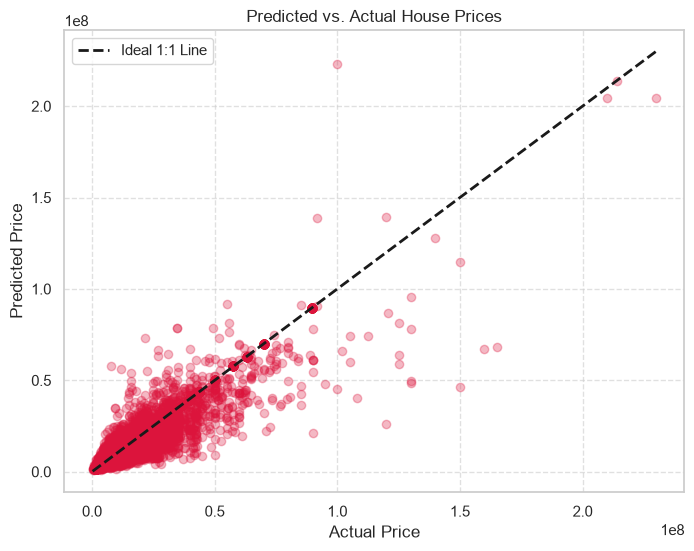

Calculating 5-Fold Cross-Validation Scores...
5-Fold CV R² Scores: [0.76734806 0.48754535 0.86059217 0.41186332 0.38242013]
Mean CV R² Score: 0.5820 (+/- 0.3895)


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# 1. Prediction using the winning model pipeline (Random Forest)
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Invert back to original price scale

# 2. Print Detailed Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Step 2.5: Final Model Performance (Random Forest) ===")
print("MAE  :", f"{mae:,.2f}")
print("RMSE :", f"{rmse:,.2f}")
print("R²   :", f"{r2:.4f}\n")

# 3. Scatter Plot: Predicted vs. Actual Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Ideal 1:1 Line")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. Actual House Prices")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Bonus: 5-Fold Cross Validation
print("Calculating 5-Fold Cross-Validation Scores...")
cv_r2_scores = cross_val_score(pipeline, X, np.log1p(y), cv=5, scoring='r2', n_jobs=-1)
print(f"5-Fold CV R² Scores: {cv_r2_scores}")
print(f"Mean CV R² Score: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std()*2:.4f})")

In [25]:
import json
import joblib
import sklearn

# 1. Save the model pipeline (using 'pipeline' variable)
joblib.dump(pipeline, "house_price.pkl")
print("Model pipeline exported to 'house_price.pkl'")

# 2. Sanity check: Reload model & predict on 1 sample
loaded_model = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]

# Predict log price and transform back to original price scale
pred_log_sample = loaded_model.predict(sample)
pred_price_sample = np.expm1(pred_log_sample)[0]

print("\n--- Sanity Check ---")
print("Sample Input Features:\n", sample)
print(f"\nReloaded prediction (Original Price Scale): {pred_price_sample:,.2f}")
print(f"Actual Target Price: {y_test.iloc[0]:,.2f}")

# 3. Save the list of allowed locations for Frontend Dropdown
location_col = 'location_clean' if 'location_clean' in df_clean.columns else 'location_grouped'
allowed_locations = sorted(df_clean[location_col].dropna().unique().tolist())

with open("locations.json", "w", encoding="utf-8") as f:
    json.dump(allowed_locations, f, ensure_ascii=False, indent=4)

print(f"\nSuccessfully saved {len(allowed_locations)} unique locations to 'locations.json'")

# 4. Version Pinning: Check scikit-learn version
print(f"\n[Version Pinning] scikit-learn version: {sklearn.__version__}")

Model pipeline exported to 'house_price.pkl'

--- Sanity Check ---
Sample Input Features:
        total_area_sqft  floor_clean  bathroom_clean  balcony_clean  \
65857           1605.0          5.0             3.0            3.0   

      location_clean   Furnishing Transaction Ownership facing  
65857        gurgaon  Unfurnished      Resale       NaN    NaN  

Reloaded prediction (Original Price Scale): 17,479,017.90
Actual Target Price: 17,500,000.00

Successfully saved 51 unique locations to 'locations.json'

[Version Pinning] scikit-learn version: 1.9.0
